In [1]:
from matplotlib import pyplot as plt
import json

from pathlib import Path

import pandas as pd

In [2]:
DIR = Path("../../artifacts/2023-08-s10/experiments/basis-accuracy")

In [58]:
def load(dataset, logit_mod, arch, layer, basis_name, basis_mode, seeds=list(range(1, 5+1))):
    
    arr_dfs = []
    for seed in seeds:
        with open(DIR / f"{dataset}-seed{seed}" / f"logit-mod-{logit_mod}" / arch / layer / f"{basis_name}--{basis_mode}" / "stats.json", "r") as fh:
            data = json.load(fh)
            
        
        df = pd.DataFrame(
            {
                "acc": data["arr_acc"],
                "k": data["arr_ks"]
            }
        )
        df["dims"] = data["dims"]

        # remark: the attribute name here is misnormzer. 
        # perhaps, we refactor it.
        df["original_acc"] = data["original_auroc"]
        df["seed"] = seed
            
        arr_dfs.append(df)
    
    df = pd.concat(arr_dfs).groupby(by="k").agg({
        "acc": ["mean", "std"],
        "seed": ["count"],
        "original_acc": ["first"],
        "dims": ["first"]
    })
    
    
    assert (df["seed"]["count"] == df["seed"]["count"].values[0]).all()

    for col in ["original_acc", "dims"]:

        assert (df[col]["first"] == df[col]["first"].values[0]).all()

    return df

load(
    "cifar100--ts1.0", 
    "oneclass", 
    "cifar100-resnet18-p1",
    "layer4", 
    "random", 
    basis_mode="centered",
    seeds=[1, 2]
)

acc            seed original_acc  dims
        mean       std count        first first
k                                              
8    0.03365  0.000919     2        0.684   512
16   0.10695  0.001485     2        0.684   512
32   0.33025  0.023264     2        0.684   512
64   0.56710  0.002121     2        0.684   512
128  0.64515  0.004879     2        0.684   512
256  0.67040  0.000283     2        0.684   512
512  0.68405  0.000071     2        0.684   512

In [59]:
load(
    "cifar100--ts1.0", 
    "oneclass", 
    "cifar100-resnet18-p1",
    "layer4", 
    "rel", 
    basis_mode="centered",
    seeds=[1, 2]
)

acc            seed original_acc  dims
        mean       std count        first first
k                                              
8    0.08100  0.000000     2        0.684   512
16   0.15620  0.000000     2        0.684   512
32   0.30545  0.000071     2        0.684   512
64   0.48110  0.000000     2        0.684   512
128  0.60415  0.000071     2        0.684   512
256  0.65680  0.000000     2        0.684   512
512  0.68410  0.000141     2        0.684   512

In [60]:
load(
    "cifar100--ts1.0", 
    "oneclass", 
    "cifar100-resnet18-p1",
    "layer4", 
    "pca", 
    basis_mode="centered",
    seeds=[1]
)

acc      seed original_acc  dims
       mean std count        first first
k                                       
8    0.2397 NaN     1        0.684   512
16   0.4095 NaN     1        0.684   512
32   0.5762 NaN     1        0.684   512
64   0.6712 NaN     1        0.684   512
128  0.6837 NaN     1        0.684   512
256  0.6838 NaN     1        0.684   512
512  0.6840 NaN     1        0.684   512

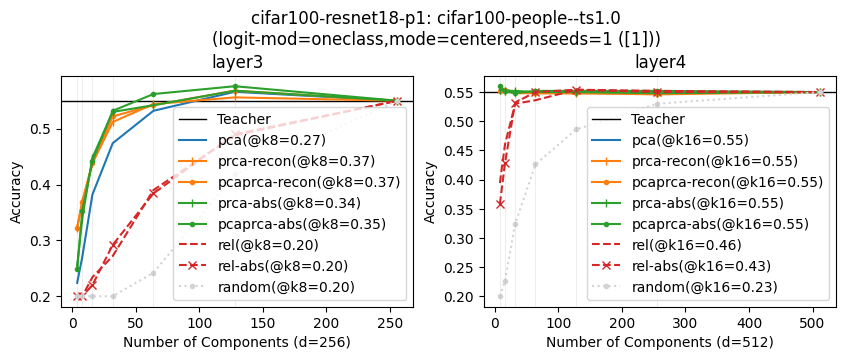

In [85]:
import numpy as np 

def color(name):
    if "random" in name:
        return "lightgray"
    elif name == "rel-abs"  or name == "act-abs":
        return plt.gca().lines[-1].get_color()
    else:
        return None

def marker(name):
    if name in ["prca-abs", "prca-recon"]:
        return "|"
    elif "pcaprca" in name:
        return "."
    elif name in ["rel-abs", "act-abs"]:
        return "x"
    elif name == "random":
        return "."
    else:
        return None
    
def ls(name):
    if "rel" in name or "act" in name:
        return "--"
    elif "random" in name:
        return ":"
    else:
        return "-"
def viz(
    dataset, 
    training_size=1.0, 
    logit_mod="oneclass", basis_mode="centered", 
    layers=["layer3", "layer4"],
    basis_names=[
        "pca",
        "prca-recon",
        "pcaprca-recon",
        "prca-abs", 
        'pcaprca-abs',
        "rel", 
        "rel-abs",
        "random", 
        
    ],
    arch = "cifar100-resnet18-p1",
    seeds=[1]
):
    
    dataset =  f"{dataset}--ts{training_size}"

    ncols = len(layers)
    plt.figure(figsize=(ncols * 5, 3))
    
    for lix, layer in enumerate(layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)
        plt.ylabel("Accuracy")
        for bix, basis_name in enumerate(basis_names):
            df = load(dataset, logit_mod, arch, layer, basis_name, basis_mode, seeds=seeds)
            d = df["dims"]["first"].values[-1]
            k = df.index

            nseeds =df["seed"]["count"].values[-1]

            if bix == 0:
                teacher_metric = df["original_acc"]["first"].values[-1]

                plt.axhline(teacher_metric, ls='-', lw=1, color="k", label="Teacher")
            
            
            vcolor = color(basis_name)
            
            if "pcaprca" in basis_name:
                vcolor = plt.gca().lines[-1].get_color()
            
            stderr = df["acc"]["std"] / (nseeds ** 0.5)
            mean = df["acc"]["mean"]
            plt.plot(
                k,
                mean,
                label=f"{basis_name}(@k{k[1]}={mean.values[1]:.2f})",
                color=vcolor,
                ls=ls(basis_name),
                marker=marker(basis_name)
            )
            
            plt.fill_between(
                k,
                mean - stderr,
                mean + stderr,
                alpha=0.5
            )
        
        for p in 1 / np.array([64, 32, 16, 8, 4, 2]):
                              
            plt.axvline(
                int(p*d), 
                ls="-", 
                lw=0.5,
                alpha=0.1,
                color="k", 
            )
        
        plt.xlabel(f"Number of Components (d={d})")

#         if lix == len(layers) - 1:
        plt.legend()
            
    plt.suptitle(f"{arch}: {dataset}\n(logit-mod={logit_mod},mode={basis_mode},nseeds={nseeds} ({seeds}))", y=1.1)

viz(
    "cifar100-people",
    layers=["layer3", "layer4"]
)


# Effect of Basis Estimation with Different Training Size `cifar100-people`

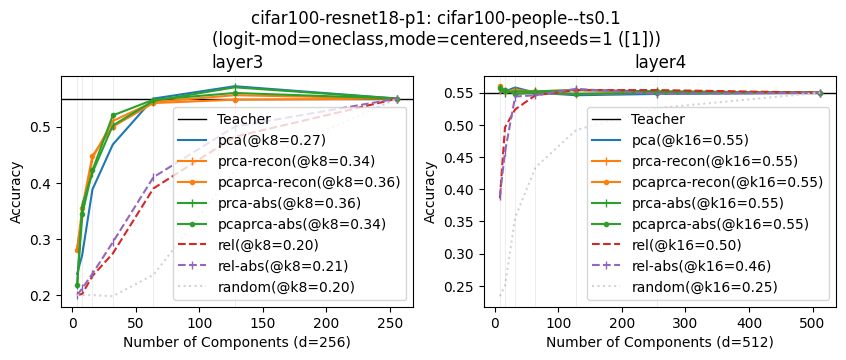

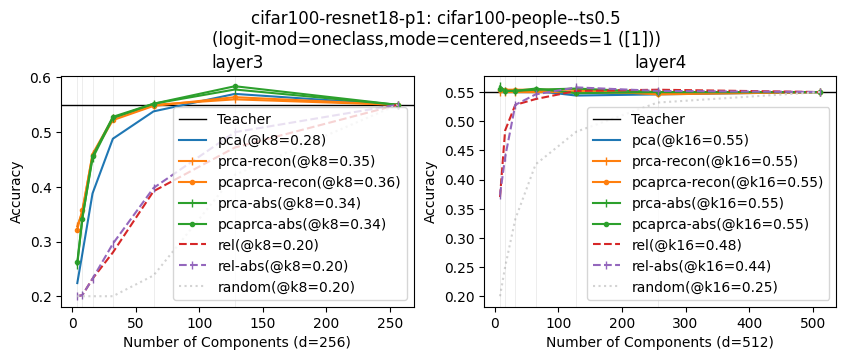

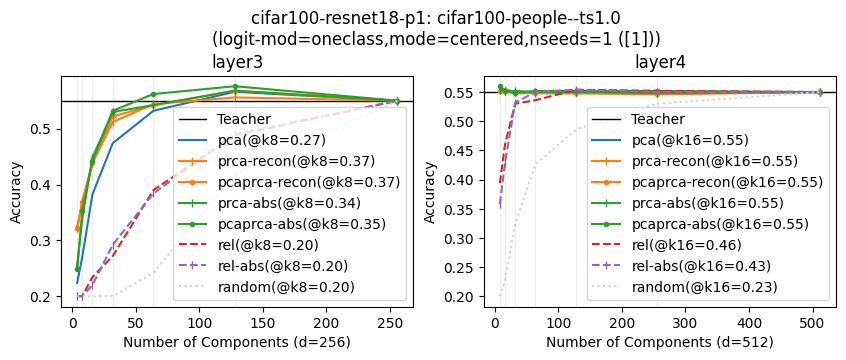

In [50]:
for ts in [0.1, 0.5, 1.0]:
    viz("cifar100-people", training_size=ts)

# Accuracy with CIFAR100 (training-size=0.01)

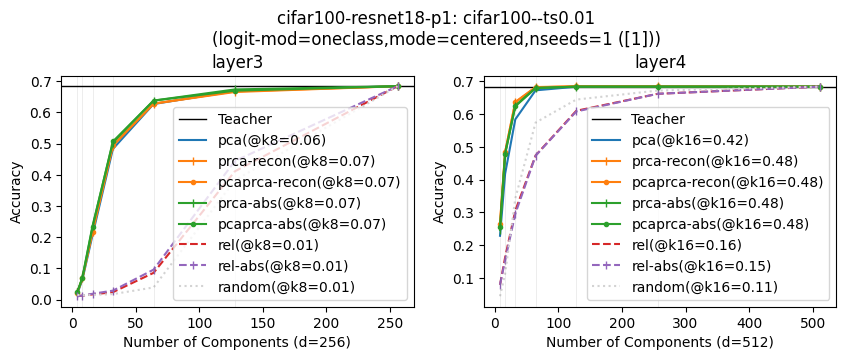

In [51]:
viz("cifar100", training_size=0.01)

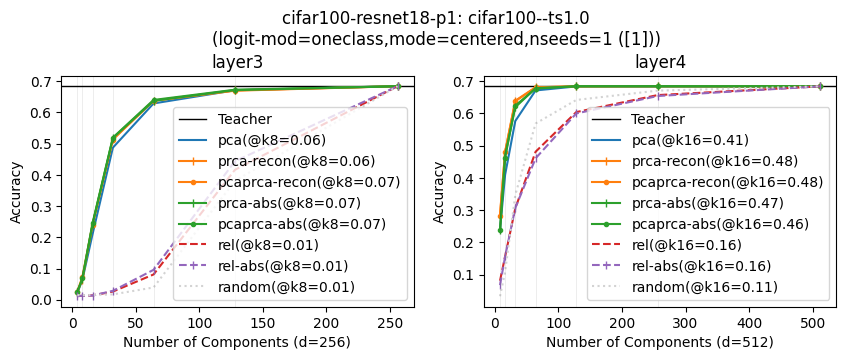

In [52]:
# remark: why is `random` better than `rel*` at `layer4`?
viz("cifar100", training_size=1.0, layers=["layer3", "layer4"])

## Follow-up why `random` is better than `rel*`

### ResNet18

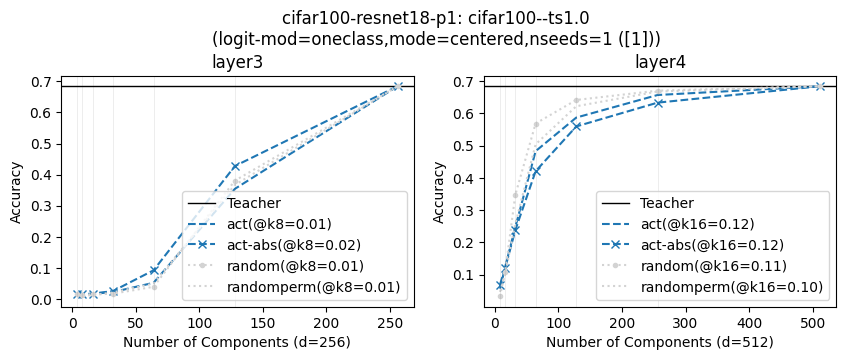

In [77]:
# remark: why is `random` better than `rel*` at `layer4`?
viz("cifar100", training_size=1.0, 
    basis_names=[
        "act", "act-abs", 
#         "rel", "rel-abs", 
        "random", "randomperm"], 
    seeds=[1]
)

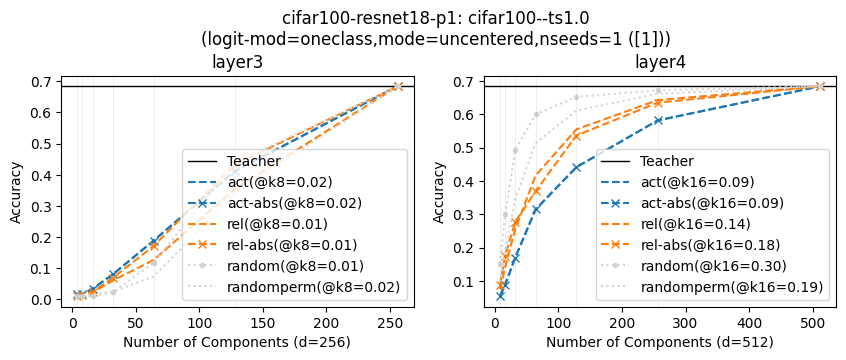

In [83]:
# remark: why is `random` better than `rel*` at `layer4`?
viz("cifar100", training_size=1.0, 
#     layers=["layer3"],
    basis_names=[
        "act", "act-abs", 
        "rel", "rel-abs", 
        "random", "randomperm"], 
    seeds=[1],
    basis_mode="uncentered"
)

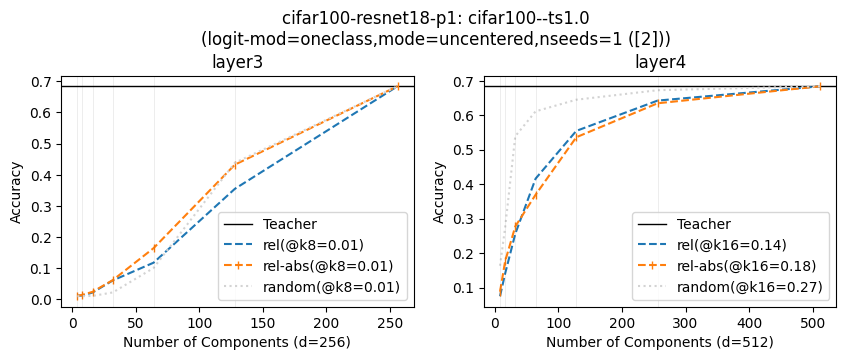

In [62]:
viz("cifar100", training_size=1.0, basis_mode="uncentered", basis_names=["rel", "rel-abs", "random"], seeds=[2])

### VGG11

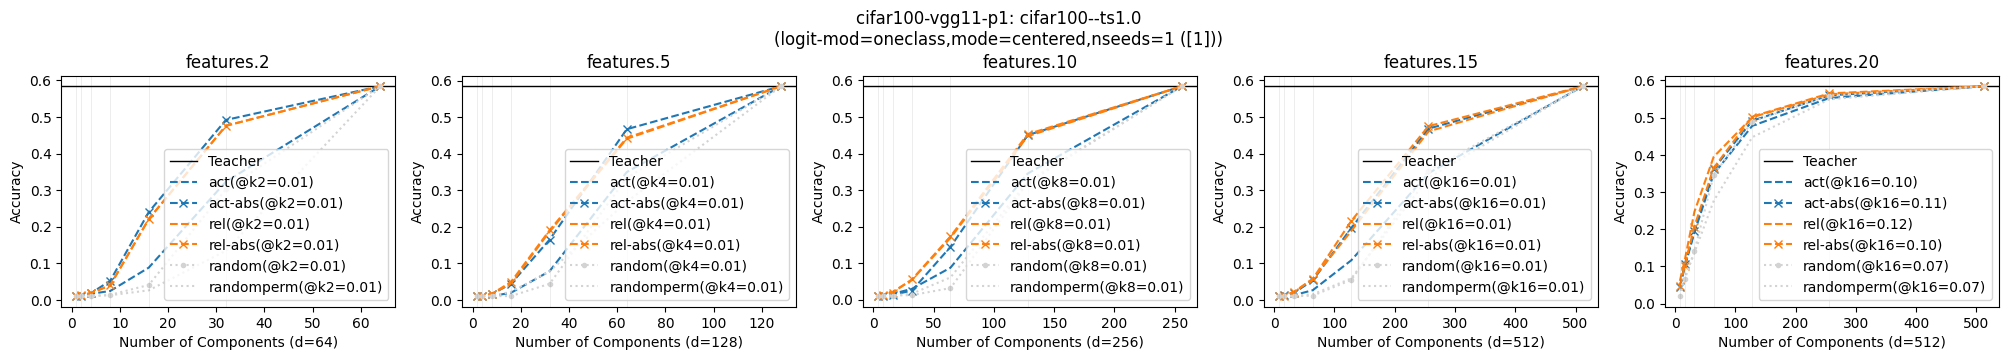

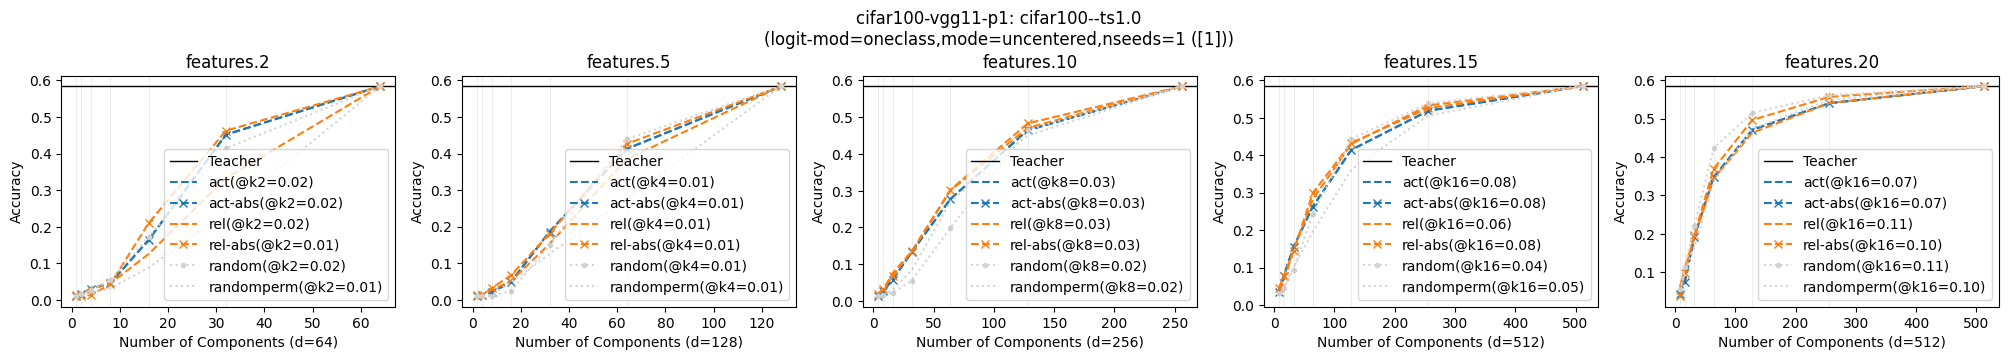

In [93]:
for basis_mode in ["centered", "uncentered"]:
    viz("cifar100", training_size=1.0, 
        layers=["features.2", "features.5", "features.10", "features.15", "features.20"],
        basis_names=[
            "act", "act-abs", 
            "rel", "rel-abs", 
            "random", "randomperm"], 
        seeds=[1],
        basis_mode=basis_mode,
        arch="cifar100-vgg11-p1"
    )

# Basis Accuracy with Different Datasets

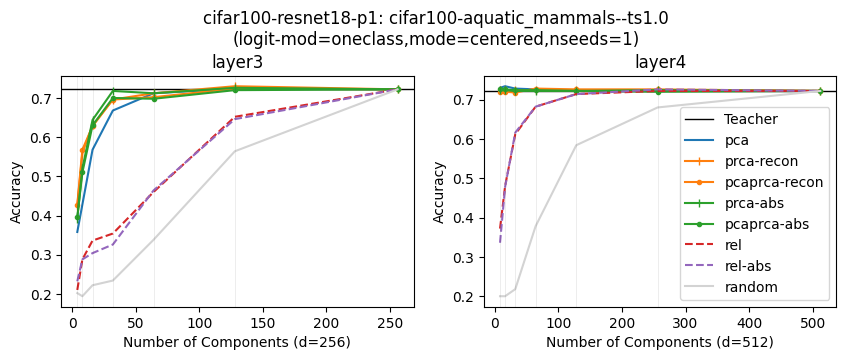

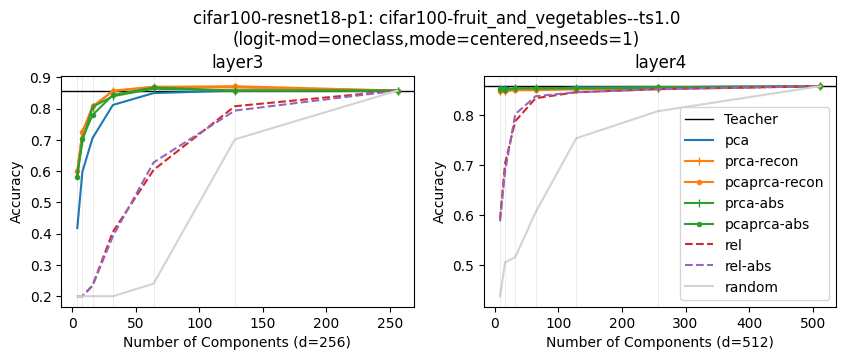

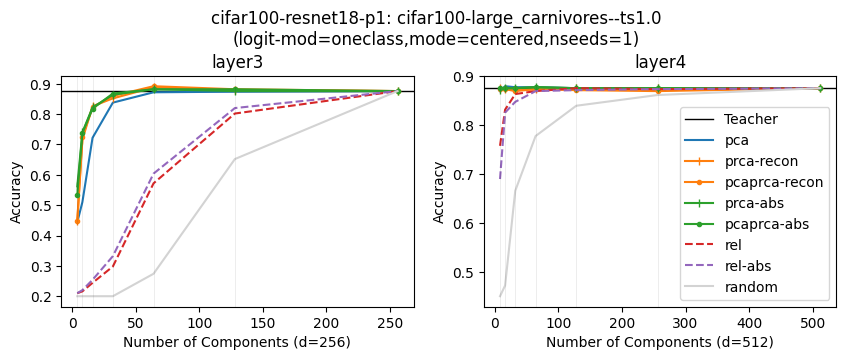

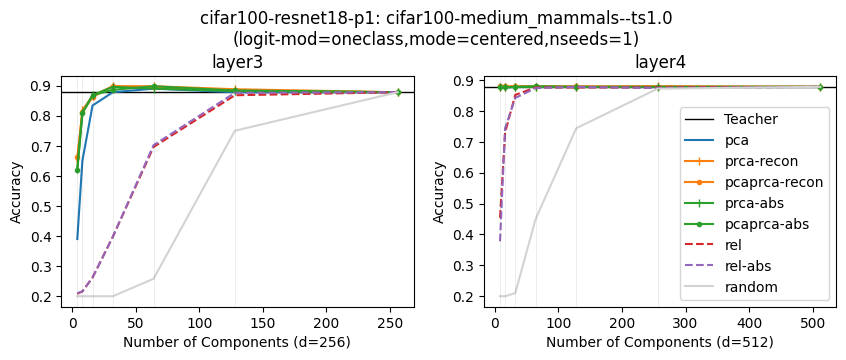

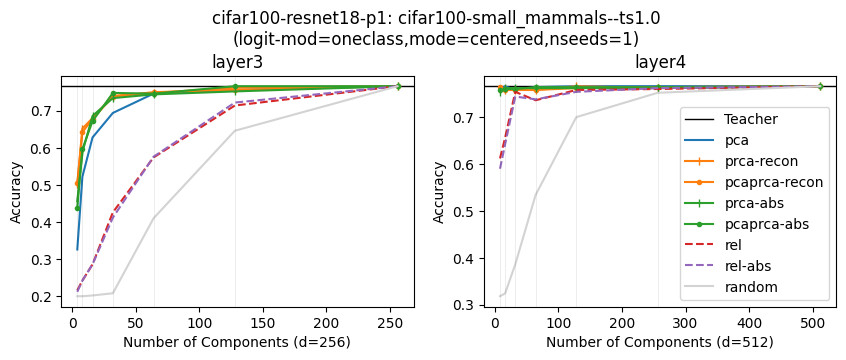

In [25]:
for dataset in [
    "cifar100-aquatic_mammals",
    "cifar100-fruit_and_vegetables",
    "cifar100-large_carnivores",
    "cifar100-medium_mammals",
    "cifar100-small_mammals",
]:
    viz(dataset, training_size=1.0, layers=["layer3", "layer4"])